# Customer Churn — Modelling

Consumes the **versioned clean dataset** produced by the data-prep step, not the raw workbook.

```
raw_data/Telco_customer_churn.xlsx
        │  python -m scripts.prepare_data   (src.data.load_raw → clean → save_clean)
        ▼
processed_data/telco_churn_clean.csv   ← committed, this notebook reads it
        │  src.model.build_pipeline  (ColumnTransformer: scale + encode, fit on train only) + classifier
        ▼
   CV → tune → evaluate on held-out set at a business-chosen threshold
```

**Models:** Logistic Regression (interpretable baseline) vs HistGradientBoosting (primary).
**Metric:** PR-AUC and recall, not accuracy — churn is ~26.5% positive.

### Setup

In [1]:
import sys
import pathlib

ROOT = pathlib.Path.cwd()
ROOT = ROOT.parent if ROOT.name == "notebook" else ROOT
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score,
    cross_val_predict,
    RandomizedSearchCV,
)
from sklearn.inspection import permutation_importance

from src import config, data
from src.model import build_pipeline, LOGREG, HIST_GBM, PARAM_DISTRIBUTIONS
from src.evaluate import (
    evaluate_model,
    choose_threshold,
    score_at_threshold,
    compare_models,
    plot_pr_curve,
    plot_confusion,
)

CV = StratifiedKFold(n_splits=config.CV_FOLDS, shuffle=True, random_state=config.RANDOM_STATE)
SCORING = "average_precision"  # = PR-AUC

### 1. Load the versioned clean dataset

If this raises `FileNotFoundError`, generate the CSV first:

```
python -m scripts.prepare_data
```

The cleaning (drop 11 columns, coerce `Total Charges`, collapse `"No internet service"` /
`"No phone service"` → `"No"`) lives in `src/data.py` and is applied once, there.

In [2]:
df = data.load_clean()
print(f"{df.shape[0]} rows x {df.shape[1]} columns   churn rate {df[config.TARGET].mean():.3f}")
df.head()

7043 rows x 22 columns   churn rate 0.265


,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,...,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value
0,33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
1,34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
2,34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1
3,34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1
4,34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,1


In [3]:
# sanity: cleaning already applied
assert df["Total Charges"].dtype.kind == "f"
assert df["Multiple Lines"].isin(["Yes", "No"]).all()
assert not set(config.DROP_COLS) & set(df.columns)
df.dtypes

Latitude             float64
Longitude            float64
Gender                   str
Senior Citizen           str
Partner                  str
Dependents               str
Tenure Months          int64
Phone Service            str
Multiple Lines           str
Internet Service         str
Online Security          str
Online Backup            str
Device Protection        str
Tech Support             str
Streaming TV             str
Streaming Movies         str
Contract                 str
Paperless Billing        str
Payment Method           str
Monthly Charges      float64
Total Charges        float64
Churn Value            int64
dtype: object

### 2. Stratified train/test split

The test set is touched exactly once, at the end. All tuning happens inside cross-validation
on the training set.

In [4]:
X_train, X_test, y_train, y_test = data.make_train_test_split(df)
print(f"train {X_train.shape}  churn {y_train.mean():.3f}")
print(f"test  {X_test.shape}  churn {y_test.mean():.3f}")

train (5634, 21)  churn 0.265
test  (1409, 21)  churn 0.265


### 3. Baseline — Logistic Regression

`build_pipeline` prepends the `ColumnTransformer`, so scaling and one-hot categories are learned
only from each CV training fold. `class_weight="balanced"` handles the imbalance.

In [5]:
logreg_pipe = build_pipeline(LOGREG)
logreg_cv = cross_val_score(logreg_pipe, X_train, y_train, scoring=SCORING, cv=CV)
print(f"Logistic Regression — CV PR-AUC {logreg_cv.mean():.3f} +/- {logreg_cv.std():.3f}")
logreg_pipe.fit(X_train, y_train)

Logistic Regression — CV PR-AUC 0.678 +/- 0.021


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](21,)","['Latitude','Longitude','Gender',...,'Payment Method','Monthly Charges', 'Total Charges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,21
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('yesno', ...), ('contract', ...), ...]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that featur

### 4. Primary model — HistGradientBoosting

In [6]:
gbm_pipe = build_pipeline(HIST_GBM)
gbm_cv = cross_val_score(gbm_pipe, X_train, y_train, scoring=SCORING, cv=CV)
print(f"HistGradientBoosting — CV PR-AUC {gbm_cv.mean():.3f} +/- {gbm_cv.std():.3f}")
gbm_pipe.fit(X_train, y_train)

HistGradientBoosting — CV PR-AUC 0.659 +/- 0.017


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](21,)","['Latitude','Longitude','Gender',...,'Payment Method','Monthly Charges', 'Total Charges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,21
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('yesno', ...), ('contract', ...), ...]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that featur

### 5. Hyperparameter tuning

`RandomizedSearchCV` over the whole pipeline — the preprocessor is refit inside every fold of
every candidate, so tuning cannot leak from the validation folds.

In [7]:
search = RandomizedSearchCV(
    build_pipeline(HIST_GBM),
    param_distributions=PARAM_DISTRIBUTIONS[HIST_GBM],
    n_iter=30,
    scoring=SCORING,
    cv=CV,
    random_state=config.RANDOM_STATE,
    n_jobs=-1,
)
search.fit(X_train, y_train)

print(f"best CV PR-AUC {search.best_score_:.3f}")
for k, v in search.best_params_.items():
    print(f"  {k.split('__')[-1]:<20} {v}")
best_model = search.best_estimator_

best CV PR-AUC 0.679
  min_samples_leaf     40
  max_leaf_nodes       15
  max_iter             400
  learning_rate        0.01


### 6. Choose an operating threshold

0.5 is arbitrary. Pick the cut-off on the **training** CV predictions (here: max F1), then apply
that fixed threshold to the test set. Swap in a recall target if a missed churner costs more than
a wasted retention offer.

In [8]:
train_proba = cross_val_predict(best_model, X_train, y_train, cv=CV, method="predict_proba")[:, 1]
threshold = choose_threshold(y_train, train_proba)
print(f"selected threshold {threshold:.3f}")
print("train @ threshold:", score_at_threshold(y_train, train_proba, threshold))

selected threshold 0.554
train @ threshold: {'threshold': 0.554, 'roc_auc': 0.8607, 'pr_auc': 0.6753, 'precision': 0.5678, 'recall': 0.7679, 'f1': 0.6528}


### 7. Held-out evaluation

In [9]:
results = {
    "logreg": evaluate_model(logreg_pipe, X_test, y_test, threshold),
    "hgb_tuned": evaluate_model(best_model, X_test, y_test, threshold),
}
compare_models(results)

,threshold,roc_auc,pr_auc,precision,recall,f1
hgb_tuned,0.554,0.8561,0.669,0.5453,0.7727,0.6394
logreg,0.554,0.8484,0.643,0.5359,0.7380,0.6209


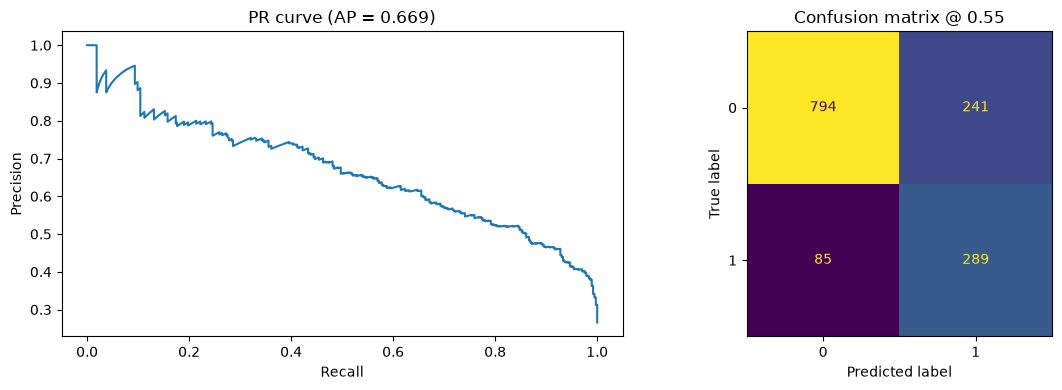

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_pr_curve(best_model, X_test, y_test, ax=axes[0])
plot_confusion(best_model, X_test, y_test, threshold, ax=axes[1])
plt.tight_layout()
plt.show()

### 8. Interpretation — permutation importance

Model-agnostic: shuffle each column in the held-out set and measure the drop in PR-AUC. Compare
the ranking against the EDA's chi-square / Cramér's V table.

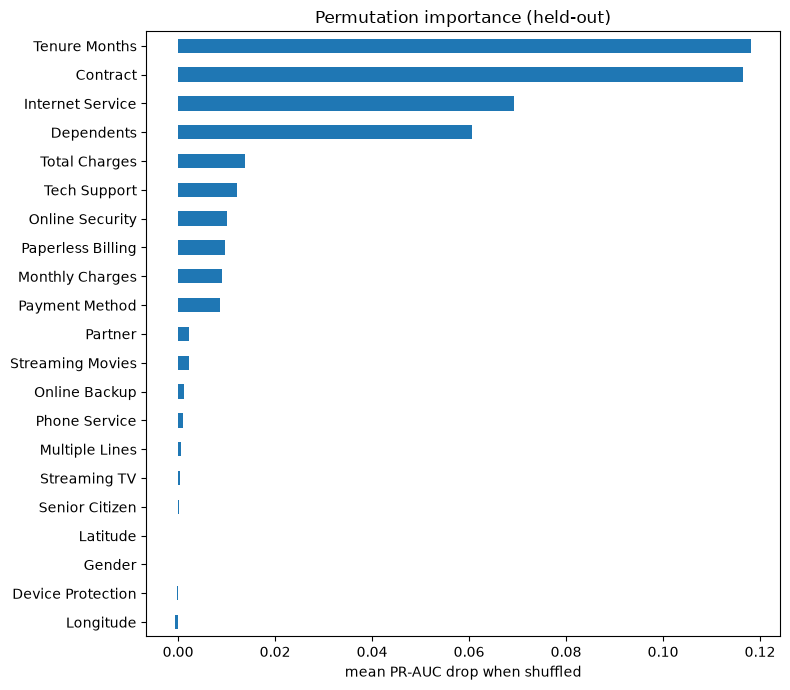

Tenure Months        0.1182
Contract             0.1164
Internet Service     0.0693
Dependents           0.0605
Total Charges        0.0138
Tech Support         0.0122
Online Security      0.0102
Paperless Billing    0.0096
Monthly Charges      0.0090
Payment Method       0.0086
Partner              0.0022
Streaming Movies     0.0022
Online Backup        0.0013
Phone Service        0.0010
Multiple Lines       0.0005
Streaming TV         0.0004
Senior Citizen       0.0002
Latitude             0.0000
Gender              -0.0000
Device Protection   -0.0003
Longitude           -0.0006
dtype: float64

In [11]:
perm = permutation_importance(
    best_model, X_test, y_test,
    scoring=SCORING, n_repeats=10, random_state=config.RANDOM_STATE, n_jobs=-1,
)
importance = (
    pd.Series(perm.importances_mean, index=X_test.columns)
    .sort_values(ascending=False)
)
ax = importance.plot.barh(figsize=(8, 7))
ax.invert_yaxis()
ax.set_xlabel("mean PR-AUC drop when shuffled")
ax.set_title("Permutation importance (held-out)")
plt.tight_layout()
plt.show()
importance.round(4)

_Optional:_ if you `pip install lightgbm` (needs `brew install libomp` on macOS), swap
`HIST_GBM` → `LIGHT_GBM` above and add a `shap.TreeExplainer(clf)` cell for signed
per-feature contributions.

## 9. Conclusion

### Performance

| model | CV PR-AUC | test PR-AUC | test ROC-AUC | precision @ 0.55 | recall @ 0.55 | F1 |
|---|---|---|---|---|---|---|
| Logistic Regression | 0.678 | 0.643 | 0.848 | 0.54 | 0.74 | 0.62 |
| HistGradientBoosting (default) | 0.659 | – | – | – | – | – |
| HistGradientBoosting (tuned) | **0.679** | **0.669** | **0.856** | 0.55 | **0.77** | **0.64** |

Reference points: predicting "never churn" scores 73.5% accuracy and **0 recall** (useless);
random-guess PR-AUC equals the churn rate, 0.265.

- **Recommended model: the tuned HistGradientBoosting pipeline** — best on every held-out metric,
  but the margin over the linear baseline is small (~2.6 PR-AUC points on test).
- The default gradient-boosting model actually *underperformed* Logistic Regression until tuning;
  the winning config is very conservative (`learning_rate=0.01`, `max_leaf_nodes=15`,
  `min_samples_leaf=40`, `max_iter=400`). The churn signal here is mostly linear and additive —
  a heavier model does not help.
- CV and test scores agree within noise → no meaningful overfitting.
- ROC-AUC ≈ 0.86 is the known ceiling for the IBM Telco dataset.

### What drives churn — permutation importance agrees with the EDA

| rank | feature | direction |
|---|---|---|
| 1 | **Tenure Months** | short tenure → churn (53% in first 6 months vs 9% after 4 years) |
| 2 | **Contract** | month-to-month → churn; two-year almost never |
| 3 | **Internet Service** | fiber-optic → churn, and the EDA showed this tracks the higher bill, not the tech |
| 4 | **Dependents** | has dependents → stays |

Everything below contributes < 0.02 PR-AUC. **`Latitude` / `Longitude` sit at ≈ 0** — the model
confirms the EDA's call that geography carries no signal; drop them from `config.NUMERIC_COLS`.
`Gender`, `Phone Service`, `Multiple Lines`, streaming, and `Senior Citizen` are all near-zero too.

### Operating point

Threshold `0.55` (max-F1 on training-fold predictions). At that cut-off the model **catches 77% of
churners at 55% precision** — ~55 of every 100 flagged customers would truly have left. Lower the
threshold to trade precision for recall if a missed churner costs more than a wasted retention
offer; the section-7 PR curve shows the full trade-off.

### Limitations & next steps

- Cross-sectional snapshot — predicts *whether* a customer churns, not *when*. A survival /
  time-to-event model on longitudinal data is the real upgrade.
- `Churn Reason` was dropped as leakage; it is a strong post-hoc explainer, not a predictor.
- Scoped experiments: CV-fold target-encoded `City` (expected null), dropping `Total Charges` for
  the linear model (collinear with `Tenure × Monthly`).
- `class_weight="balanced"` handled the 2.8 : 1 imbalance; SMOTE was not needed.

### Bottom line

Ship `src.model.build_pipeline("hgb")` tuned as above. Keep Logistic Regression as the interpretable
reference — it is within 2–3 points on every metric and its coefficients tell the same story. The
value for the business is the driver story (tenure, contract, price), which both models agree on.